# Credit Card Fraud Detection

**An end-to-end machine learning pipeline for identifying fraudulent credit card transactions**

This notebook walks through the complete workflow of building a fraud detection system: understanding the business problem, exploring and cleaning the data, engineering useful features, training several classification models, and evaluating and interpreting the results.

---

## Table of Contents

1. [Business Understanding](#1.-Business-Understanding)
2. [Data Loading & Understanding](#2.-Data-Loading-&-Understanding)
3. [Data Cleaning](#3.-Data-Cleaning)
4. [Exploratory Data Analysis (EDA)](#4.-Exploratory-Data-Analysis-(EDA))
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Data Preprocessing](#6.-Data-Preprocessing)
7. [Model Training](#7.-Model-Training)
8. [Model Evaluation](#8.-Model-Evaluation)
9. [Feature Importance & Explainability](#9.-Feature-Importance-&-Explainability)
10. [Conclusion & Next Steps](#10.-Conclusion-&-Next-Steps)

---

# 1. Business Understanding

## 1.1 Problem Statement

Credit card fraud is a major challenge for banks and financial institutions. Every day, thousands of credit card transactions are processed, and a small percentage of them may be fraudulent. Detecting fraudulent transactions quickly and accurately is important to reduce financial losses and protect customers.

The main challenge is that fraudulent transactions are extremely rare compared to legitimate transactions. Therefore, a machine learning model must be able to identify fraudulent transactions while minimizing false alarms for legitimate customers.

This project aims to develop a machine learning-based fraud detection system that can classify credit card transactions as either **legitimate** or **fraudulent**.

---

## 1.2 Business Objective

The business objective of this project is to help banks and financial institutions:

- Detect potentially fraudulent transactions automatically.
- Reduce financial losses caused by credit card fraud.
- Identify high-risk transactions for further investigation.
- Reduce the amount of manual fraud detection work.
- Improve customer protection and transaction security.

The system should prioritize detecting fraudulent transactions while keeping the number of legitimate transactions incorrectly flagged as fraud as low as possible.

---

## 1.3 Machine Learning Objective

The machine learning objective is to build a **binary classification model** that predicts whether a credit card transaction is:

- **0 — Legitimate Transaction**
- **1 — Fraudulent Transaction**

The project will follow an end-to-end machine learning pipeline consisting of:

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing
6. Model Training
7. Model Evaluation
8. Feature Importance and Model Explainability

Multiple classification algorithms will be evaluated to identify a suitable model for detecting fraudulent transactions.

---

## 1.4 Success Metrics

Because fraudulent transactions represent a very small proportion of the total dataset, **accuracy alone is not an appropriate measure of model performance**.

The following metrics will be used:

### Recall

Recall measures the percentage of actual fraudulent transactions that the model successfully detects.

**Formula:**

Recall = True Positives / (True Positives + False Negatives)

A high recall is important because failing to detect a fraudulent transaction can result in financial losses.

### Precision

Precision measures how many transactions predicted as fraudulent are actually fraudulent.

**Formula:**

Precision = True Positives / (True Positives + False Positives)

High precision helps reduce the number of legitimate customers whose transactions are incorrectly flagged as fraud.

### F1 Score

The F1 Score combines Precision and Recall into a single metric.

**Formula:**

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

It is useful for evaluating the balance between detecting fraud and avoiding false fraud alerts.

### ROC-AUC

ROC-AUC measures how effectively the model can distinguish between legitimate and fraudulent transactions across different classification thresholds.

A higher ROC-AUC indicates better overall classification performance.

---

## 1.5 Business Success Criteria

The final model will be considered successful if it can:

- Detect a high proportion of fraudulent transactions.
- Maintain a reasonable precision to avoid excessive false alerts.
- Achieve a strong F1 Score.
- Demonstrate good ROC-AUC performance.
- Provide interpretable information about which features contribute most to fraud predictions.

> **Important:** Since fraud detection is an imbalanced classification problem, the project will prioritize **Recall, Precision, F1 Score, and ROC-AUC** rather than relying on accuracy alone.

# 2. Data Loading & Understanding

This section loads the raw dataset and performs an initial inspection: dataset shape, column names, data types, missing values, and the balance of the target variable. The goal is to build a clear picture of the data before any cleaning or modeling begins.

## 2.1 Load the Dataset

The credit card fraud dataset is loaded into a Pandas DataFrame from the CSV file path. The `head()` function displays the first five records to provide an initial view of the transaction data and verify that it loaded correctly.

In [3]:
# Import pandas
import pandas as pd

# Load the dataset
file_path = "/content/creditcard.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 2.2 Dataset Structure

Next, the shape, column names, and data types of the dataset are examined to understand its overall structure.

In [4]:
# Number of rows and columns
rows, columns = df.shape

print(f"Number of rows    : {rows:,}")
print(f"Number of columns : {columns}")

Number of rows    : 73,377
Number of columns : 31


In [5]:
# Display all column names
print("Dataset Columns:")
print("-" * 40)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

Dataset Columns:
----------------------------------------
 1. Time
 2. V1
 3. V2
 4. V3
 5. V4
 6. V5
 7. V6
 8. V7
 9. V8
10. V9
11. V10
12. V11
13. V12
14. V13
15. V14
16. V15
17. V16
18. V17
19. V18
20. V19
21. V20
22. V21
23. V22
24. V23
25. V24
26. V25
27. V26
28. V27
29. V28
30. Amount
31. Class


In [6]:
# Display data types and non-null information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73377 entries, 0 to 73376
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    73377 non-null  int64  
 1   V1      73377 non-null  float64
 2   V2      73377 non-null  float64
 3   V3      73377 non-null  float64
 4   V4      73377 non-null  float64
 5   V5      73377 non-null  float64
 6   V6      73377 non-null  float64
 7   V7      73377 non-null  float64
 8   V8      73377 non-null  float64
 9   V9      73377 non-null  float64
 10  V10     73377 non-null  float64
 11  V11     73377 non-null  float64
 12  V12     73377 non-null  float64
 13  V13     73377 non-null  float64
 14  V14     73377 non-null  float64
 15  V15     73377 non-null  float64
 16  V16     73377 non-null  float64
 17  V17     73377 non-null  float64
 18  V18     73377 non-null  float64
 19  V19     73377 non-null  float64
 20  V20     73377 non-null  float64
 21  V21     73377 non-null  float64
 22

In [7]:
# Data type summary
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values
})

dtype_summary

,Column,Data Type,Non-Null Count,Missing Values
0,Time,int64,73377,0
1,V1,float64,73377,0
2,V2,float64,73377,0
3,V3,float64,73377,0
4,V4,float64,73377,0
5,V5,float64,73377,0
6,V6,float64,73377,0
7,V7,float64,73377,0
8,V8,float64,73377,0
9,V9,float64,73377,0


In [8]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [9]:
# Define target variable
target = "Class"

print(f"Target Variable: {target}")

print("\nTarget Variable Values:")
print(df[target].value_counts())

Target Variable: Class

Target Variable Values:
Class
0.0    73198
1.0      178
Name: count, dtype: int64


## 2.3 Data Dictionary

A data dictionary is built to document each feature: its data type, missing values, number of unique values, and a short description. Because the `V1`–`V28` features are PCA-transformed for confidentiality, they are documented generically, while `Time`, `Amount`, and `Class` are described explicitly.

In [10]:
# Create a basic data dictionary
data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Feature,Data Type,Missing Values,Unique Values
0,Time,int64,0,34689
1,V1,float64,0,71795
2,V2,float64,0,71795
3,V3,float64,0,71795
4,V4,float64,0,71795
5,V5,float64,0,71795
6,V6,float64,0,71795
7,V7,float64,0,71795
8,V8,float64,0,71795
9,V9,float64,0,71795


In [11]:
# Feature descriptions
feature_descriptions = {
    "Time": "Seconds elapsed between this transaction and the first transaction in the dataset.",
    "Amount": "Transaction amount.",
    "Class": "Target variable: 0 = legitimate transaction, 1 = fraudulent transaction."
}

# Add descriptions for PCA-transformed features
for column in df.columns:
    if column.startswith("V"):
        feature_descriptions[column] = (
            "PCA-transformed numerical feature. "
            "Original feature details are not provided for confidentiality."
        )

# Add descriptions to data dictionary
data_dictionary["Description"] = data_dictionary["Feature"].map(feature_descriptions)

data_dictionary

,Feature,Data Type,Missing Values,Unique Values,Description
0,Time,int64,0,34689,Seconds elapsed between this transaction and t...
1,V1,float64,0,71795,PCA-transformed numerical feature. Original fe...
2,V2,float64,0,71795,PCA-transformed numerical feature. Original fe...
3,V3,float64,0,71795,PCA-transformed numerical feature. Original fe...
4,V4,float64,0,71795,PCA-transformed numerical feature. Original fe...
5,V5,float64,0,71795,PCA-transformed numerical feature. Original fe...
6,V6,float64,0,71795,PCA-transformed numerical feature. Original fe...
7,V7,float64,0,71795,PCA-transformed numerical feature. Original fe...
8,V8,float64,0,71795,PCA-transformed numerical feature. Original fe...
9,V9,float64,0,71795,PCA-transformed numerical feature. Original fe...


## 2.4 Dataset Summary

This step provides a concise overview of the credit card fraud dataset. It displays the total number of rows and columns, checks for missing values and duplicate records, identifies the target variable, and shows the number of legitimate and fraudulent transactions. This summary helps verify the overall quality and structure of the dataset before moving to the data cleaning stage.

In [12]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum():,}")
print(f"Duplicate Rows    : {df.duplicated().sum():,}")
print(f"Target Variable   : {target}")
print(f"Legitimate        : {(df[target] == 0).sum():,}")
print(f"Fraudulent        : {(df[target] == 1).sum():,}")
print("=" * 50)

DATASET SUMMARY
Rows              : 73,377
Columns           : 31
Missing Values    : 5
Duplicate Rows    : 282
Target Variable   : Class
Legitimate        : 73,198
Fraudulent        : 178


# 3. Data Cleaning

In this phase, the dataset is prepared for reliable analysis and machine learning. Missing values are checked, duplicate transactions are identified and removed, and data types are validated to ensure consistency. Invalid values, such as negative transaction amounts or time values, are also checked. Finally, transaction amount outliers are inspected using the IQR method. Outliers are not automatically removed because unusually large transactions may contain important information for fraud detection.

The result of this phase is a clean and consistent dataset that is ready for exploratory data analysis and feature engineering.

In [13]:
# Check and remove duplicates
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 282
Dataset shape after removing duplicates: (73095, 31)


In [14]:
# Check data types
print(df.dtypes)

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object


In [15]:
# Check for invalid values in Amount and Time
print("Negative Amounts:", (df["Amount"] < 0).sum())
print("Negative Time:", (df["Time"] < 0).sum())

Negative Amounts: 0
Negative Time: 0


In [16]:
# Calculate IQR for transaction Amount
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

print("Number of Amount outliers:", len(outliers))

Number of Amount outliers: 7706


In [17]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (73095, 31)
Missing values: 5
Duplicate rows: 0


# 4. Exploratory Data Analysis (EDA)

This section explores the cleaned dataset visually and statistically to understand the class imbalance, the distribution of transaction amounts, how fraud relates to transaction time, and which features correlate most strongly with fraud. These insights directly inform the feature engineering and modeling decisions that follow.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 4.1 Class Distribution

Fraud detection is a highly imbalanced classification problem. The plot and counts below show just how rare fraudulent transactions are relative to legitimate ones.

Transaction Counts:
Class
0.0    72916
1.0      178
Name: count, dtype: int64

Fraud Percentage:
0.244%


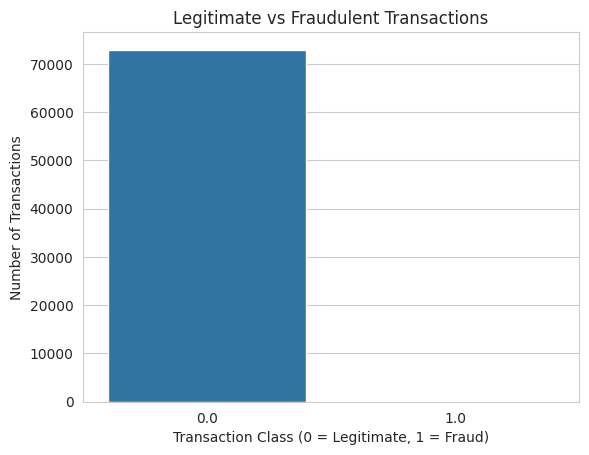

In [19]:
# Class distribution
class_counts = df["Class"].value_counts()

print("Transaction Counts:")
print(class_counts)

print("\nFraud Percentage:")
print(f"{(df['Class'].mean() * 100):.3f}%")

sns.countplot(data=df, x="Class")
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

## 4.2 Transaction Amount Analysis

Next, the distribution of transaction amounts is examined overall and by class, to see whether fraudulent transactions tend to differ in size from legitimate ones.

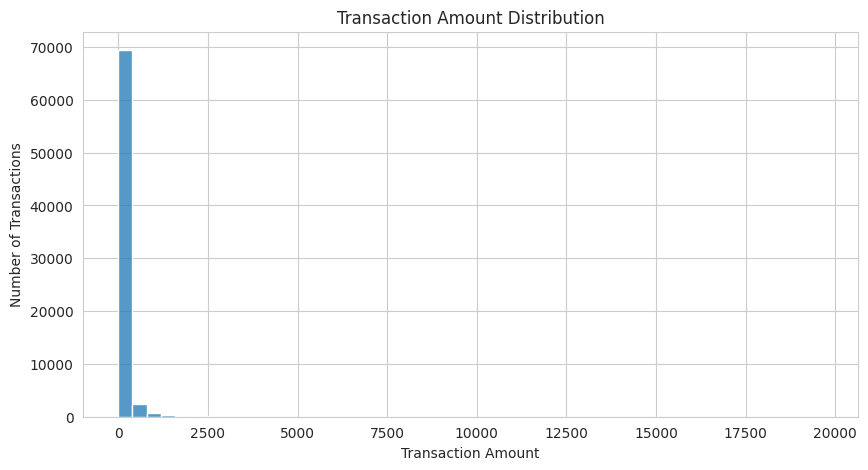

In [20]:
# Transaction amount distribution
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

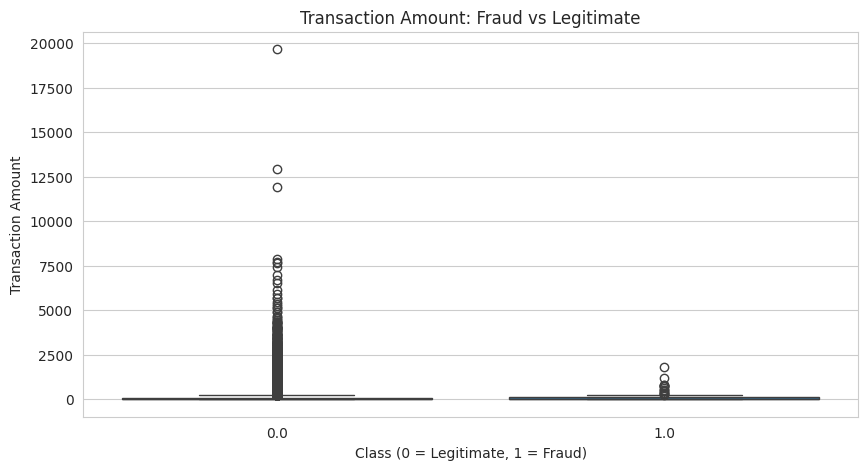

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

In [22]:
df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
Class,,,,
0.0,72916,97.506622,26.880,19656.53
1.0,178,95.191461,7.595,1809.68


## 4.3 Correlation Analysis

To identify which features are most associated with fraudulent activity, correlations between all features and the `Class` target are calculated, and the top 10 most correlated features are visualized as a heatmap.

<Figure size 1400x1000 with 0 Axes>

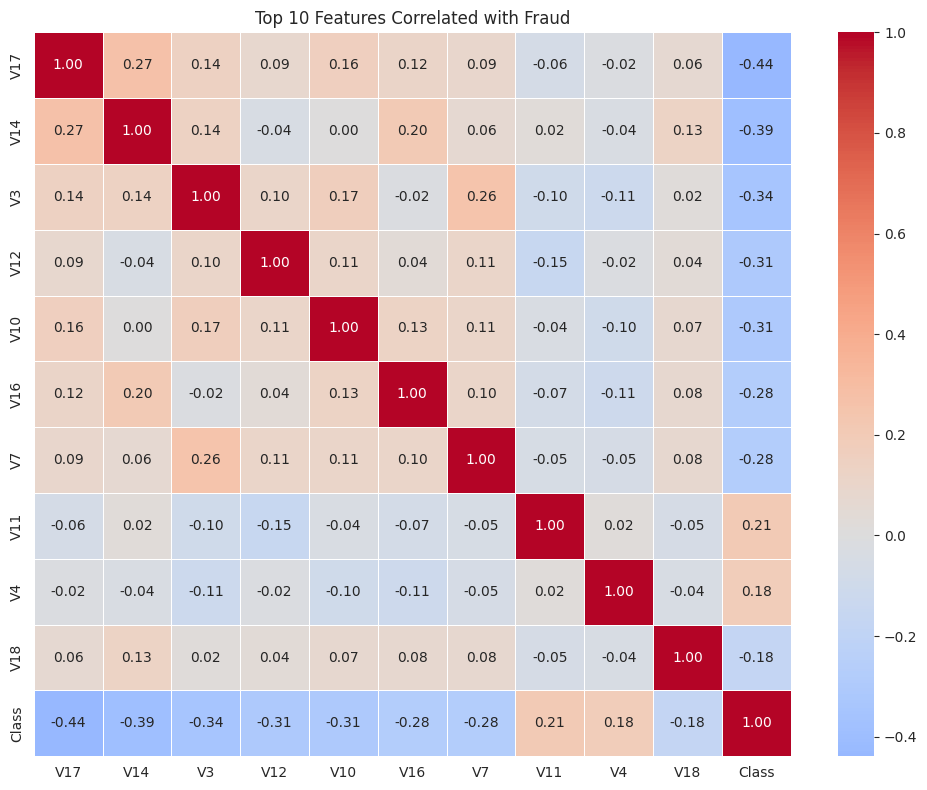

In [23]:
plt.figure(figsize=(14, 10))

correlation = df.corr()

# Top 10 features correlated with fraud
top_features = (
    df.corr()["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

corr_top = df[list(top_features) + ["Class"]].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_top,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Top 10 Features Correlated with Fraud")
plt.tight_layout()
plt.show()

In [24]:
# Correlation with target variable
fraud_correlation = df.corr()["Class"].sort_values(ascending=False)

print(fraud_correlation)

Class     1.000000
V11       0.205424
V4        0.184341
V2        0.146499
V8        0.131505
V27       0.072842
V21       0.056662
V19       0.050158
V20       0.024459
V25       0.012887
V26       0.008126
V28       0.006342
V13       0.005964
V15       0.001811
Amount   -0.000422
V24      -0.006438
V22      -0.006621
V23      -0.015835
Time     -0.016446
V6       -0.082617
V9       -0.135422
V5       -0.170101
V1       -0.172695
V18      -0.180300
V7       -0.275874
V16      -0.280605
V10      -0.305223
V12      -0.308404
V3       -0.343777
V14      -0.391490
V17      -0.438948
Name: Class, dtype: float64


In [25]:
fraud_correlation.drop("Class").abs().sort_values(ascending=False).head(10)

,Class
V17,0.438948
V14,0.391490
V3,0.343777
V12,0.308404
V10,0.305223
V16,0.280605
V7,0.275874
V11,0.205424
V4,0.184341
V18,0.180300


## 4.4 Fraud Patterns Over Time

The `Time` feature (seconds since the first transaction) is converted to an hour-of-day value to check whether fraud rates vary across the day.

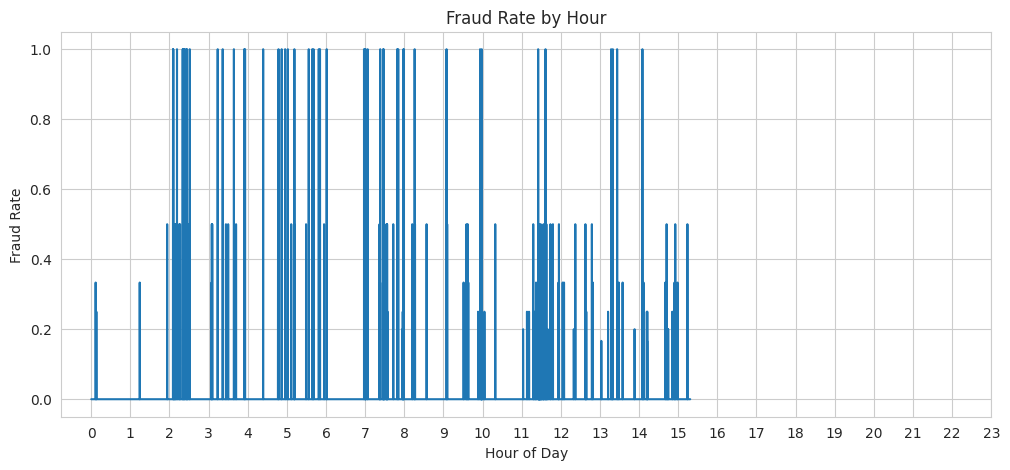

In [26]:
# Convert Time from seconds to hours
df["Hour"] = (df["Time"] / 3600) % 24

fraud_by_hour = df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(12, 5))

plt.plot(fraud_by_hour.index, fraud_by_hour.values)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.xticks(range(0, 24))
plt.show()

## 4.5 Outlier Inspection

Boxplots of the transaction amount and a sample of the PCA-transformed features (`V1`–`V5`) are used to visually inspect the presence of outliers, which are common indicators of anomalous (potentially fraudulent) behavior.

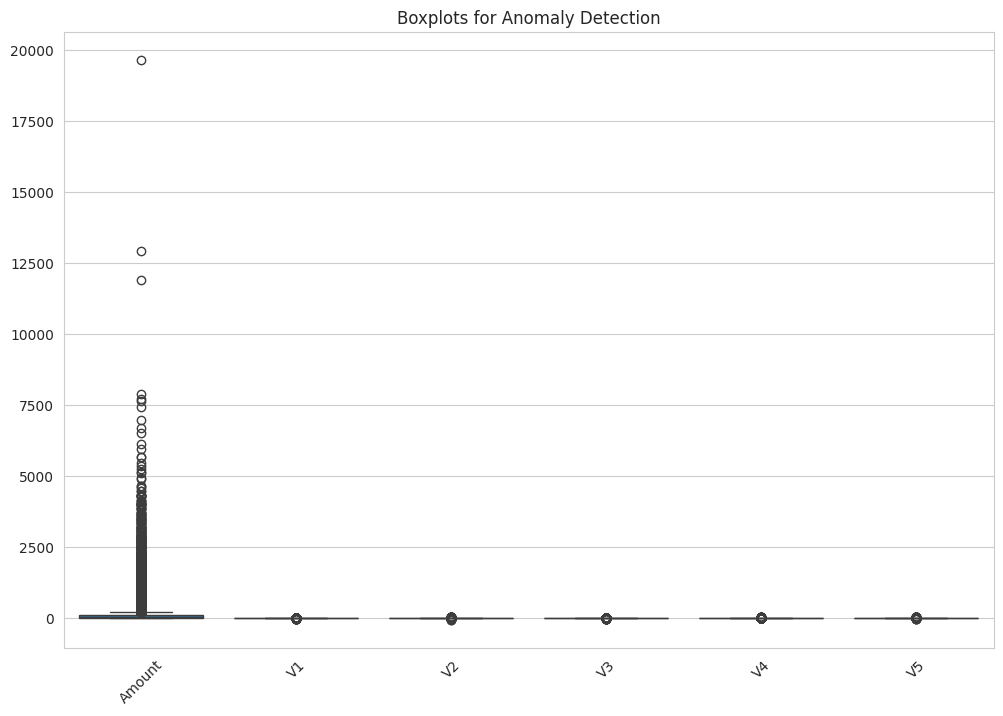

In [27]:
# Boxplots for Amount and selected PCA features
features = ["Amount", "V1", "V2", "V3", "V4", "V5"]

plt.figure(figsize=(12, 8))

sns.boxplot(data=df[features])

plt.title("Boxplots for Anomaly Detection")
plt.xticks(rotation=45)
plt.show()

## 4.6 Key Findings

1. Fraudulent transactions represent a very small percentage of all transactions.
2. Transaction amounts show a highly skewed distribution.
3. Fraudulent and legitimate transactions show differences in their amount distributions.
4. Several PCA-transformed features show stronger correlation with the fraud target.
5. Fraud rates vary across transaction times.
6. Some numerical variables contain significant outliers.

# 5. Feature Engineering

Building on the patterns found during EDA, this section creates new features designed to help the models better separate fraudulent from legitimate transactions: the hour of day, a day/night indicator, a log-scaled transaction amount, a categorical amount bucket, and a high-value transaction flag.

In [28]:
import numpy as np
import pandas as pd

# Create hour of transaction
df["Hour"] = (df["Time"] / 3600) % 24

# Day / Night indicator
df["Day_Night"] = df["Hour"].apply(
    lambda x: "Night" if x < 6 or x >= 22 else "Day"
)

# Log transaction amount
df["Log_Amount"] = np.log1p(df["Amount"])

# Transaction amount category
df["Amount_Category"] = pd.cut(
    df["Amount"],
    bins=[-1, 10, 50, 200, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

# High-value transaction flag
high_value_threshold = df["Amount"].quantile(0.95)

df["High_Value"] = (df["Amount"] > high_value_threshold).astype(int)

In [29]:
# Display newly created features
df[
    ["Time", "Amount", "Hour", "Day_Night",
     "Log_Amount", "Amount_Category", "High_Value"]
].head()

,Time,Amount,Hour,Day_Night,Log_Amount,Amount_Category,High_Value
0,0,149.62,0.000000,Night,5.014760,High,0
1,0,2.69,0.000000,Night,1.305626,Low,0
2,1,378.66,0.000278,Night,5.939276,Very High,0
3,1,123.50,0.000278,Night,4.824306,High,0
4,2,69.99,0.000556,Night,4.262539,High,0


In [30]:
print(f"High-value threshold: {high_value_threshold:.2f}")

High-value threshold: 393.54


In [31]:
print("New features created:")
print([
    "Hour",
    "Day_Night",
    "Log_Amount",
    "Amount_Category",
    "High_Value"
])

New features created:
['Hour', 'Day_Night', 'Log_Amount', 'Amount_Category', 'High_Value']


# 6. Data Preprocessing

Before training, the data is split into training and testing sets, numerical and categorical features are prepared for modeling (scaling and one-hot encoding), and class imbalance in the training set is corrected using SMOTE. The test set is kept untouched by resampling so that model evaluation reflects real-world class proportions.

## 6.1 Train-Test Split

The features (`X`) and target (`y`) are separated, and the dataset is split into training and testing sets using stratified sampling to preserve the fraud/legitimate ratio in both sets.

In [32]:
from sklearn.model_selection import train_test_split

# Drop rows with NaN values in the target variable 'Class' before splitting
df.dropna(subset=["Class"], inplace=True)

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (73094, 35)
Target: (73094,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (58475, 35)
Testing set : (14619, 35)


## 6.2 Encoding & Scaling Pipeline

A `ColumnTransformer` is defined to standardize the numerical features and one-hot encode the categorical features (`Day_Night`, `Amount_Category`) created during feature engineering. Wrapping this in a single preprocessor keeps the transformation consistent between training and test data and prevents data leakage.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ["Day_Night", "Amount_Category"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [35]:
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 6.3 Handling Class Imbalance (SMOTE)

Because fraudulent transactions are so rare, the preprocessing pipeline is extended with **SMOTE** (Synthetic Minority Over-sampling Technique), which generates synthetic fraud examples in the training set so that models are not biased toward always predicting the majority (legitimate) class. SMOTE is applied only to the training data, never to the test data.

In [36]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

preprocessing_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42))
])

In [37]:
X_train_processed, y_train_processed = preprocessing_pipeline.fit_resample(
    X_train, y_train
)

In [38]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_processed.value_counts())

Before SMOTE:
Class
0.0    58333
1.0      142
Name: count, dtype: int64

After SMOTE:
Class
0.0    58333
1.0    58333
Name: count, dtype: int64


# 7. Model Training

Four classification algorithms are trained on the resampled, preprocessed training data: Logistic Regression, Decision Tree, Random Forest, and XGBoost. Comparing multiple model types helps identify which approach best captures the patterns that distinguish fraud from legitimate activity.

## 7.1 Define Candidate Models

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [40]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

## 7.2 Train Models

Each model is fit on the SMOTE-resampled training data and stored for evaluation in the next section.

In [41]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train_processed)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


In [42]:
print("\nTrained Models:")
for name in trained_models:
    print("-", name)


Trained Models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


# 8. Model Evaluation

Each trained model is evaluated on the untouched, non-resampled test set. Precision, Recall, F1 Score, and ROC-AUC are computed for every model, alongside confusion matrices and precision-recall curves, in line with the success metrics defined in the Business Understanding section. The best model is then selected based on Recall, since missing fraudulent transactions is the costliest type of error.

## 8.1 Transform the Test Set

The test set is transformed using the **already-fitted** preprocessor only (no SMOTE), so evaluation reflects the true, imbalanced distribution of transactions.

In [43]:
# Transform test data (NO SMOTE)
X_test_processed = preprocessing_pipeline.named_steps["preprocessor"].transform(X_test)

## 8.2 Performance Metrics

Precision, Recall, F1 Score, and ROC-AUC are calculated for each model and compared side by side.

In [44]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("Recall", ascending=False)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.072917,0.972222,0.135659,0.991590
1,Decision Tree,0.255639,0.944444,0.402367,0.970769
3,XGBoost,0.829268,0.944444,0.883117,0.995882
2,Random Forest,0.888889,0.888889,0.888889,0.996826


## 8.3 Confusion Matrices

Confusion matrices show exactly how many legitimate and fraudulent transactions each model classified correctly versus incorrectly, making the trade-off between false positives and false negatives easy to see.

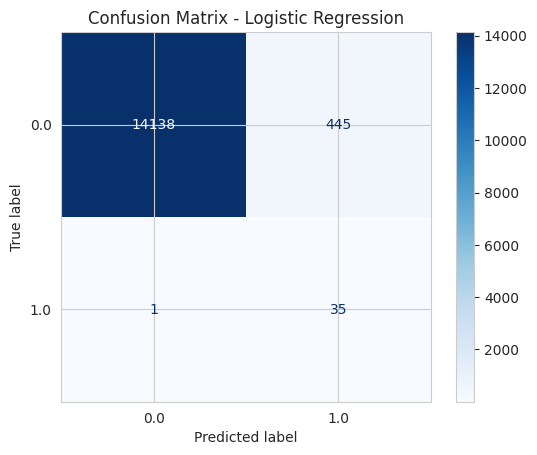

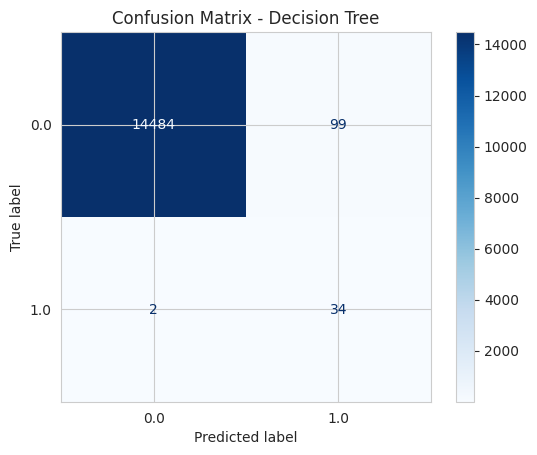

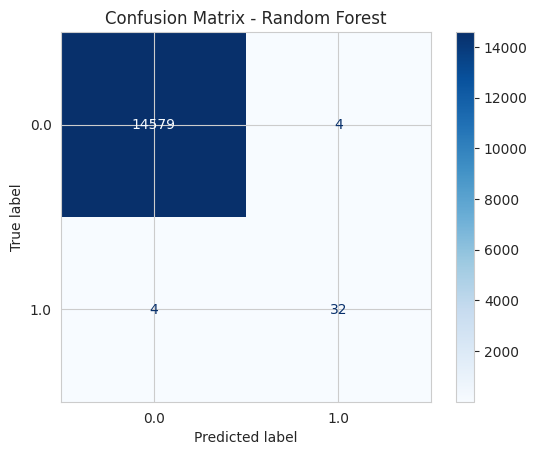

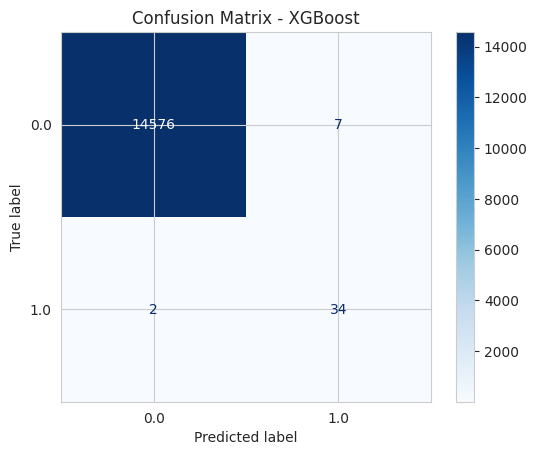

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in trained_models.items():

    y_pred = model.predict(X_test_processed)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## 8.4 Precision-Recall Curve

Because the dataset is highly imbalanced, the precision-recall curve is a more informative diagnostic than the ROC curve for comparing model performance across classification thresholds.

<Figure size 1000x600 with 0 Axes>

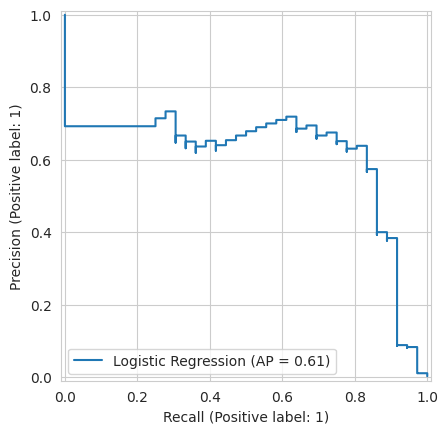

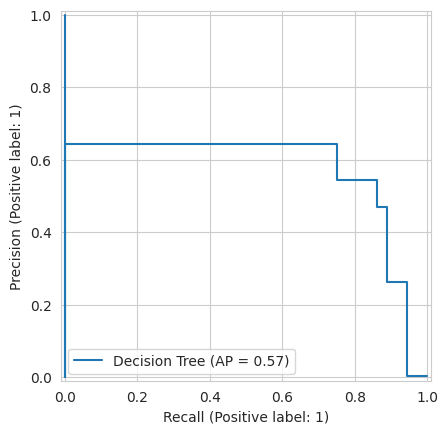

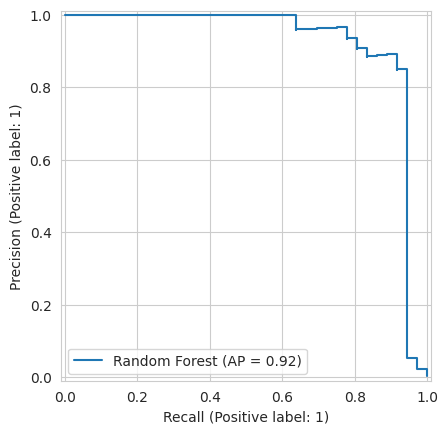

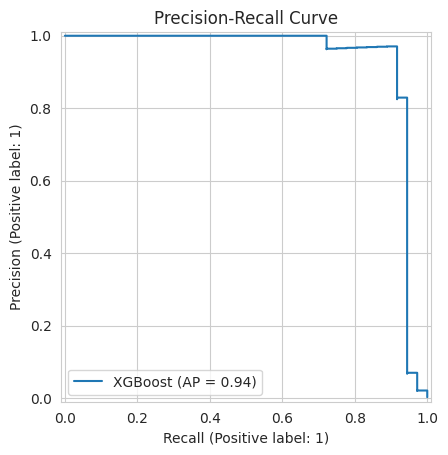

In [46]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 6))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_processed)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

plt.title("Precision-Recall Curve")
plt.show()

## 8.5 Select the Best Model

Consistent with the business success criteria, the model with the highest **Recall** is selected as the best-performing model, since it detects the largest proportion of actual fraudulent transactions.

In [47]:
best_model_name = results_df.loc[
    results_df["Recall"].idxmax(), "Model"
]

print("Best model based on Recall:", best_model_name)

Best model based on Recall: Logistic Regression


In [48]:
best_model = trained_models[best_model_name]

print(best_model)

LogisticRegression(max_iter=1000, random_state=42)


# 9. Feature Importance & Explainability

To make the model's decisions interpretable, this section examines which features most influence fraud predictions using two complementary methods: the Random Forest's built-in feature importances, and permutation importance, which measures the drop in performance when a feature's values are shuffled.

## 9.1 Retrieve Feature Names

Since the preprocessing pipeline transforms the raw features (scaling and one-hot encoding), the resulting feature names are retrieved from the fitted preprocessor.

In [49]:
# Get feature names after preprocessing
feature_names = preprocessing_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Total features:", len(feature_names))

Total features: 39


## 9.2 Random Forest Feature Importance

The Random Forest model's built-in importance scores show which features it relied on most heavily when splitting the data.

In [50]:
# Random Forest model
rf_model = trained_models["Random Forest"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Top 10 features
top_10 = importance.head(10)

print("Top 10 Features:")
print(top_10)

Top 10 Features:
num__V14    0.171757
num__V11    0.138617
num__V10    0.111035
num__V17    0.096727
num__V12    0.070656
num__V3     0.055738
num__V4     0.053264
num__V16    0.040089
num__V7     0.037151
num__V2     0.022906
dtype: float64


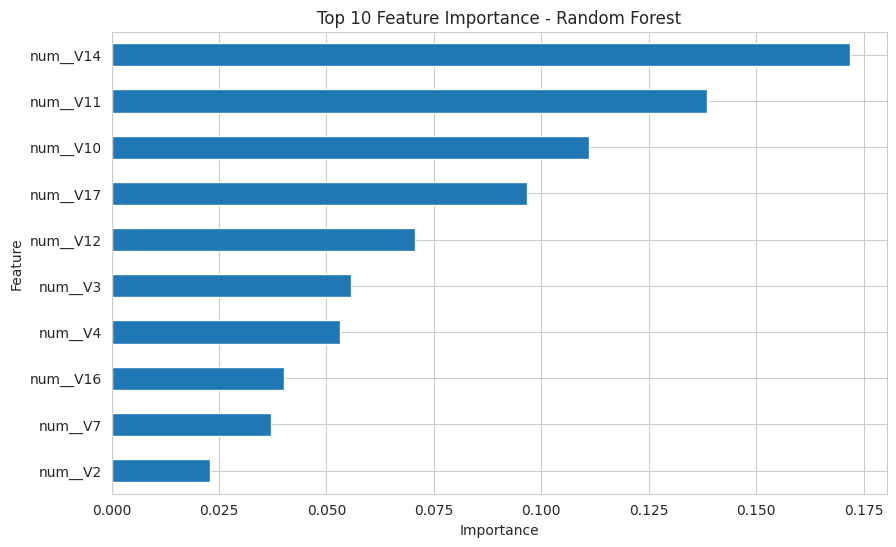

In [51]:
plt.figure(figsize=(10, 6))

top_10.sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 9.3 Permutation Importance

Permutation importance provides a model-agnostic sanity check on feature relevance by measuring how much the F1 Score drops when each feature is randomly shuffled, breaking its relationship with the target.

In [52]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_names
).sort_values(ascending=False)

top_10_perm = perm_importance.head(10)

print("Top 10 Permutation Features:")
print(top_10_perm)

Top 10 Permutation Features:
num__V14    0.835688
num__V11    0.289921
num__V12    0.140688
num__V3     0.036062
num__V4     0.030930
num__V26    0.030158
num__V16    0.028527
num__V17    0.025307
num__V10    0.021537
num__V20    0.021537
dtype: float64


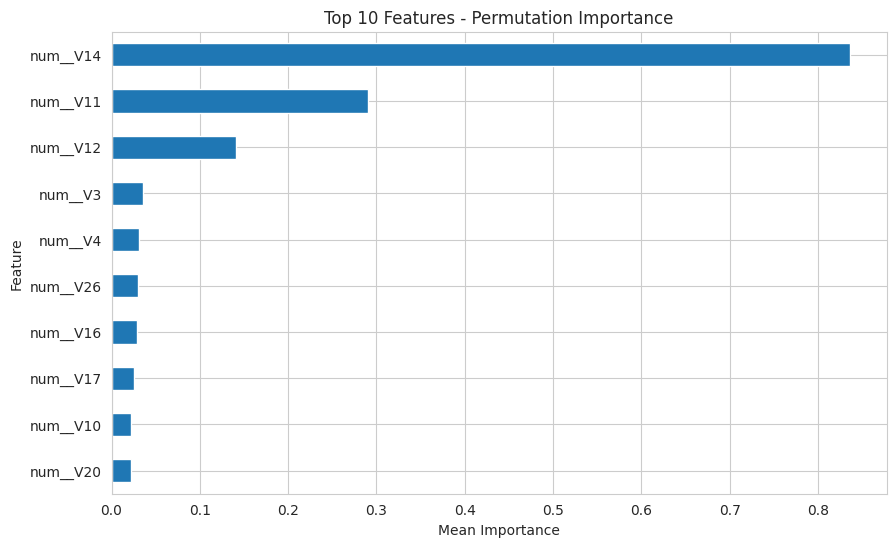

In [53]:
plt.figure(figsize=(10, 6))

top_10_perm.sort_values().plot(kind="barh")

plt.title("Top 10 Features - Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

# 10. Conclusion & Next Steps

## 10.1 Summary

This notebook followed a complete fraud detection workflow: exploring and cleaning the transaction data, engineering time- and amount-based features, correcting class imbalance with SMOTE, and training and comparing four classification models. Models were evaluated primarily on **Recall**, in line with the business objective of catching as many fraudulent transactions as possible, while Precision, F1 Score, and ROC-AUC were tracked to keep false alerts in check. Feature importance analysis (Random Forest importances and permutation importance) was used to make the final model's predictions interpretable.

## 10.2 Possible Next Steps

- **Threshold tuning:** Adjust the classification threshold (rather than using the default 0.5) to further optimize the Precision/Recall trade-off for business needs.
- **Hyperparameter tuning:** Use grid search or Bayesian optimization to fine-tune the best-performing model.
- **Additional models:** Evaluate anomaly-detection approaches (e.g., Isolation Forest, Autoencoders) that are well suited to extreme class imbalance.
- **Cost-sensitive evaluation:** Incorporate the real financial cost of false negatives vs. false positives into model selection.
- **Deployment monitoring:** If deployed, monitor for data/concept drift, since fraud patterns evolve over time.